In [2]:
import os
import random
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
import torchmetrics
import matplotlib.pyplot as plt

# Force matplotlib to display inline
%matplotlib inline 

class Config:
    DATA_PATH = "/kaggle/input/protien-image" 
    IMG_SIZE = 512
    CHANNELS = 1  
    SAMPLE_LIMIT = 20000 
    
    # VQ-VAE-2 Specifics
    EMBED_DIM = 64         # Size of the codebook vectors
    NUM_EMBEDDINGS = 512   # How many "words" in the codebook dictionary
    
    # Training Params
    BATCH_SIZE = 8   
    EPOCHS = 50 
    LR = 3e-4        # VQ-VAE likes slightly lower LR standard Adam
    PATIENCE = 5    
    
    SAVE_DIR = "./results_vqvae2"
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(Config.SAVE_DIR, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything()
print(f"VQ-VAE-2 Configuration loaded on: {Config.DEVICE}")

VQ-VAE-2 Configuration loaded on: cuda


In [3]:
class GrayscaleDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        try:
            image = Image.open(img_path).convert('L')
            if self.transform:
                image = self.transform(image)
            return image
        except Exception as e:
            return torch.zeros((1, Config.IMG_SIZE, Config.IMG_SIZE))

def get_data_loaders():
    print("Scanning files...")
    all_files = []
    for root, dirs, files in os.walk(Config.DATA_PATH):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.bmp')):
                all_files.append(os.path.join(root, file))
    
    print(f"✅ Found {len(all_files)} images.")
    if len(all_files) > Config.SAMPLE_LIMIT:
        all_files = all_files[:Config.SAMPLE_LIMIT]
    
    train_files, test_files = train_test_split(all_files, test_size=0.2, random_state=42)
    val_files, test_files = train_test_split(test_files, test_size=0.5, random_state=42)

    transform = transforms.Compose([
        transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
        transforms.ToTensor(), 
    ])

    train_loader = DataLoader(GrayscaleDataset(train_files, transform), batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(GrayscaleDataset(val_files, transform), batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(GrayscaleDataset(test_files, transform), batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_data_loaders()

Scanning files...
✅ Found 124288 images.


In [4]:
# --- 1. The Vector Quantizer ---
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25):
        super(VectorQuantizer, self).__init__()
        self._embedding_dim = embedding_dim
        self._num_embeddings = num_embeddings
        self._commitment_cost = commitment_cost
        
        self._embedding = nn.Embedding(self._num_embeddings, self._embedding_dim)
        self._embedding.weight.data.uniform_(-1/self._num_embeddings, 1/self._num_embeddings)

    def forward(self, inputs):
        inputs = inputs.permute(0, 2, 3, 1).contiguous()
        input_shape = inputs.shape
        flat_input = inputs.view(-1, self._embedding_dim)
        
        distances = (torch.sum(flat_input**2, dim=1, keepdim=True) 
                    + torch.sum(self._embedding.weight**2, dim=1)
                    - 2 * torch.matmul(flat_input, self._embedding.weight.t()))
            
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(encoding_indices.shape[0], self._num_embeddings, device=inputs.device)
        encodings.scatter_(1, encoding_indices, 1)
        
        quantized = torch.matmul(encodings, self._embedding.weight).view(input_shape)
        
        e_latent_loss = F.mse_loss(quantized.detach(), inputs)
        q_latent_loss = F.mse_loss(quantized, inputs.detach())
        loss = q_latent_loss + self._commitment_cost * e_latent_loss
        
        quantized = inputs + (quantized - inputs).detach()
        return quantized.permute(0, 3, 1, 2).contiguous(), loss, encoding_indices

# --- 2. Residual Block (Fixed inplace=False) ---
class ResBlock(nn.Module):
    def __init__(self, dim):
        super(ResBlock, self).__init__()
        self.block = nn.Sequential(
            nn.ReLU(False), # Fixed
            nn.Conv2d(dim, dim, 3, 1, 1),
            nn.ReLU(False), # Fixed
            nn.Conv2d(dim, dim, 1)
        )
    def forward(self, x):
        return x + self.block(x)

# --- 3. Main VQ-VAE-2 Model ---
class VQVAE2(nn.Module):
    def __init__(self):
        super(VQVAE2, self).__init__()
        dim = 128
        
        # --- ENCODER BOTTOM ---
        self.enc_b = nn.Sequential(
            nn.Conv2d(1, dim // 2, 4, 2, 1),
            nn.ReLU(False),
            nn.Conv2d(dim // 2, dim, 4, 2, 1),
            nn.ReLU(False),
            ResBlock(dim),
            ResBlock(dim)
        )
        
        # --- ENCODER TOP ---
        self.enc_t = nn.Sequential(
            nn.Conv2d(dim, dim, 4, 2, 1),
            nn.ReLU(False),
            ResBlock(dim),
            ResBlock(dim)
        )
        
        # --- QUANTIZERS ---
        self.quantize_t = VectorQuantizer(Config.NUM_EMBEDDINGS, Config.EMBED_DIM)
        self.quantize_b = VectorQuantizer(Config.NUM_EMBEDDINGS, Config.EMBED_DIM)
        
        # --- PRE-QUANTIZATION CONVS ---
        self.quant_conv_t = nn.Conv2d(dim, Config.EMBED_DIM, 1)
        # Fixed: Input is (128 from Bottom) + (128 from Top Decoder) = 256
        self.quant_conv_b = nn.Conv2d(dim + dim, Config.EMBED_DIM, 1) 
        
        # --- DECODER TOP ---
        self.dec_t = nn.Sequential(
            nn.Conv2d(Config.EMBED_DIM, dim, 3, 1, 1),
            ResBlock(dim),
            ResBlock(dim),
            nn.ConvTranspose2d(dim, dim, 4, 2, 1),
            nn.ReLU(False)
        )
        
        # --- DECODER BOTTOM ---
        self.dec_b = nn.Sequential(
            nn.Conv2d(Config.EMBED_DIM + dim, dim, 3, 1, 1),
            ResBlock(dim),
            ResBlock(dim),
            nn.ConvTranspose2d(dim, dim // 2, 4, 2, 1),
            nn.ReLU(False),
            nn.ConvTranspose2d(dim // 2, 1, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 1. Encode
        enc_b = self.enc_b(x)
        enc_t = self.enc_t(enc_b)
        
        # 2. Quantize Top
        quant_t, loss_t, _ = self.quantize_t(self.quant_conv_t(enc_t))
        
        # 3. Decode Top
        dec_t = self.dec_t(quant_t)
        
        # 4. Quantize Bottom (Concat Features)
        feat_b = torch.cat([enc_b, dec_t], dim=1) 
        quant_b, loss_b, _ = self.quantize_b(self.quant_conv_b(feat_b))
        
        # 5. Final Decode
        dec_input = torch.cat([quant_b, dec_t], dim=1)
        recon = self.dec_b(dec_input)
        
        return recon, loss_t + loss_b

In [5]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

def vq_loss_function(recon, target, codebook_loss):
    # MSE is standard for VQ-VAE reconstruction
    recon_loss = F.mse_loss(recon, target)
    return recon_loss + codebook_loss, recon_loss

In [6]:
import warnings
warnings.filterwarnings("ignore")


In [7]:
model = VQVAE2().to(Config.DEVICE)
optimizer = optim.Adam(model.parameters(), lr=Config.LR) 
early_stopper = EarlyStopping(patience=Config.PATIENCE)

# Metrics
ssim_metric = torchmetrics.StructuralSimilarityIndexMeasure(data_range=1.0).to(Config.DEVICE)
psnr_metric = torchmetrics.PeakSignalNoiseRatio(data_range=1.0).to(Config.DEVICE)

print("VQ-VAE-2 Initialized (Fixed Version).")

history = {
    "epoch": [], "train_loss": [], "val_loss": [], 
    "val_ssim": [], "val_psnr": []
}
best_ssim = -1.0

print(f"Starting VQ-VAE-2 Training...")

for epoch in range(Config.EPOCHS):
    start_time = time.time()
    
    # --- TRAIN ---
    model.train()
    train_loss = 0.0
    for images in train_loader:
        images = images.to(Config.DEVICE)
        optimizer.zero_grad()
        
        recon, codebook_loss = model(images)
        loss, _ = vq_loss_function(recon, images, codebook_loss)
        
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    
    # --- VALIDATE ---
    model.eval()
    val_loss = 0.0
    val_ssim = 0.0
    val_psnr = 0.0
    
    with torch.no_grad():
        for images in val_loader:
            images = images.to(Config.DEVICE)
            recon, codebook_loss = model(images)
            
            loss, _ = vq_loss_function(recon, images, codebook_loss)
            val_loss += loss.item()
            
            val_ssim += ssim_metric(recon, images).item()
            val_psnr += psnr_metric(recon, images).item()
            
    val_loss /= len(val_loader)
    val_ssim /= len(val_loader)
    val_psnr /= len(val_loader)
    
    # --- LOGGING ---
    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_ssim"].append(val_ssim)
    history["val_psnr"].append(val_psnr)
    
    print(f"Epoch [{epoch+1}/{Config.EPOCHS}] "
          f"Loss: {val_loss:.5f} | "
          f"SSIM: {val_ssim:.4f} | PSNR: {val_psnr:.2f}dB "
          f"({time.time() - start_time:.1f}s)")
    
    if val_ssim > best_ssim:
        best_ssim = val_ssim
        torch.save(model.state_dict(), os.path.join(Config.SAVE_DIR, "best_vqvae2.pth"))
        print(f"--> New Best VQ-VAE-2 Saved (SSIM: {best_ssim:.4f})")
    
    early_stopper(val_loss)
    if early_stopper.early_stop:
        print(f"🛑 Early stopping triggered at Epoch {epoch+1}!")
        break

pd.DataFrame(history).to_csv(os.path.join(Config.SAVE_DIR, "vqvae2_log.csv"), index=False)

VQ-VAE-2 Initialized (Fixed Version).
Starting VQ-VAE-2 Training...
Epoch [1/50] Loss: 0.02536 | SSIM: 0.5410 | PSNR: 16.23dB (574.0s)
--> New Best VQ-VAE-2 Saved (SSIM: 0.5410)
Epoch [2/50] Loss: 0.02535 | SSIM: 0.5410 | PSNR: 16.23dB (573.0s)
Epoch [3/50] Loss: 0.02535 | SSIM: 0.5410 | PSNR: 16.23dB (572.5s)
Epoch [4/50] Loss: 0.02534 | SSIM: 0.5410 | PSNR: 16.23dB (572.7s)
Epoch [5/50] Loss: 0.02534 | SSIM: 0.5410 | PSNR: 16.23dB (572.4s)
Epoch [6/50] Loss: 0.00383 | SSIM: 0.7630 | PSNR: 24.94dB (573.0s)
--> New Best VQ-VAE-2 Saved (SSIM: 0.7630)
Epoch [7/50] Loss: 0.00380 | SSIM: 0.8076 | PSNR: 25.93dB (572.5s)
--> New Best VQ-VAE-2 Saved (SSIM: 0.8076)
Epoch [8/50] Loss: 0.00371 | SSIM: 0.8337 | PSNR: 26.50dB (573.1s)
--> New Best VQ-VAE-2 Saved (SSIM: 0.8337)
Epoch [9/50] Loss: 0.00356 | SSIM: 0.8389 | PSNR: 26.69dB (572.6s)
--> New Best VQ-VAE-2 Saved (SSIM: 0.8389)
Epoch [10/50] Loss: 0.00414 | SSIM: 0.8478 | PSNR: 26.95dB (572.7s)
--> New Best VQ-VAE-2 Saved (SSIM: 0.8478)
Epo

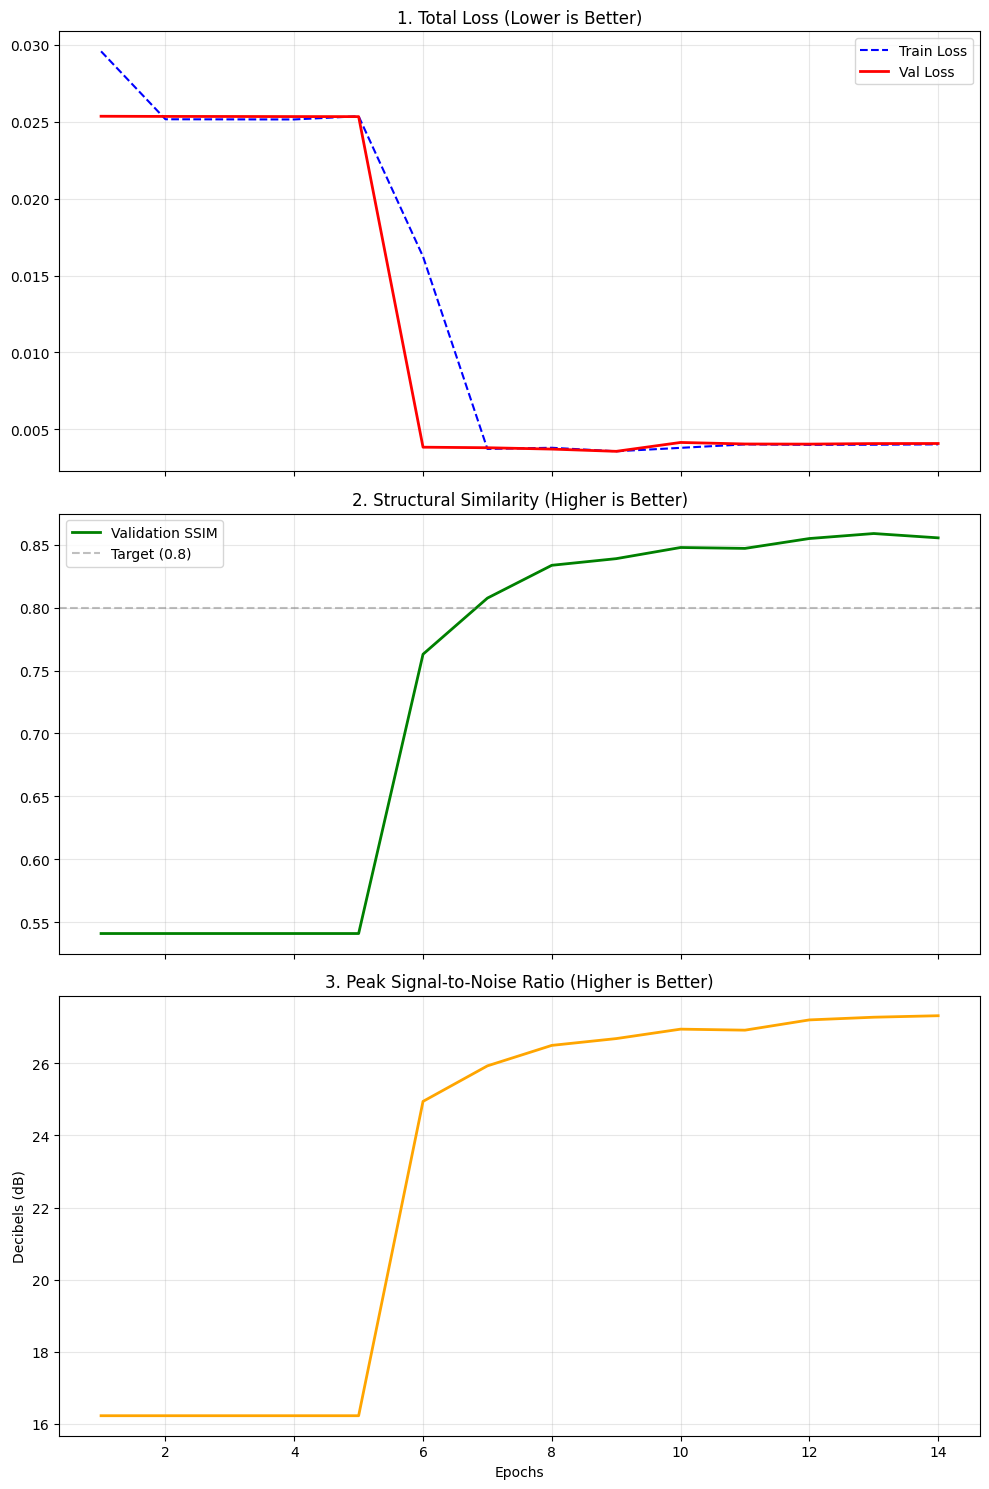

In [8]:
def plot_vqvae_training_graphs():
    # Detect which log file exists
    if os.path.exists(os.path.join(Config.SAVE_DIR, "vqvae2_lpips_log.csv")):
        log_path = os.path.join(Config.SAVE_DIR, "vqvae2_lpips_log.csv")
        has_lpips = True
    else:
        log_path = os.path.join(Config.SAVE_DIR, "vqvae2_log.csv")
        has_lpips = False
        
    if not os.path.exists(log_path):
        print("❌ Log file not found. Run training first.")
        return
    
    df = pd.read_csv(log_path)
    epochs = df['epoch']
    
    # Create subplots (4 if LPIPS, 3 if not)
    rows = 4 if has_lpips else 3
    fig, axes = plt.subplots(rows, 1, figsize=(10, 5 * rows), sharex=True)
    
    # 1. Total Loss
    axes[0].plot(epochs, df['train_loss'], label='Train Loss', color='blue', linestyle='--')
    axes[0].plot(epochs, df['val_loss'], label='Val Loss', color='red', linewidth=2)
    axes[0].set_title("1. Total Loss (Lower is Better)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. SSIM
    axes[1].plot(epochs, df['val_ssim'], label='Validation SSIM', color='green', linewidth=2)
    axes[1].set_title("2. Structural Similarity (Higher is Better)")
    axes[1].axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Target (0.8)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 3. PSNR
    axes[2].plot(epochs, df['val_psnr'], label='Validation PSNR', color='orange', linewidth=2)
    axes[2].set_title("3. Peak Signal-to-Noise Ratio (Higher is Better)")
    axes[2].set_ylabel("Decibels (dB)")
    axes[2].grid(True, alpha=0.3)
    
    # 4. LPIPS (If available)
    if has_lpips:
        axes[3].plot(epochs, df['val_lpips'], label='Validation LPIPS', color='purple', linewidth=2)
        axes[3].set_title("4. Perceptual Loss (Lower is Better)")
        axes[3].set_xlabel("Epochs")
        axes[3].grid(True, alpha=0.3)
    else:
        axes[2].set_xlabel("Epochs")
    
    plt.tight_layout()
    plt.savefig(os.path.join(Config.SAVE_DIR, "vqvae2_training_graphs.png"))
    plt.show()

plot_vqvae_training_graphs()

In [9]:
def display_vqvae_metrics_text():
    # Detect log file
    if os.path.exists(os.path.join(Config.SAVE_DIR, "vqvae2_lpips_log.csv")):
        log_path = os.path.join(Config.SAVE_DIR, "vqvae2_lpips_log.csv")
        has_lpips = True
    elif os.path.exists(os.path.join(Config.SAVE_DIR, "vqvae2_log.csv")):
        log_path = os.path.join(Config.SAVE_DIR, "vqvae2_log.csv")
        has_lpips = False
    else:
        print("❌ Log file not found.")
        return
    
    df = pd.read_csv(log_path)
    final_row = df.iloc[-1]
    best_ssim_row = df.loc[df['val_ssim'].idxmax()]
    best_psnr_row = df.loc[df['val_psnr'].idxmax()]
    
    print("="*60)
    print(f"       VQ-VAE-2 TRAINING REPORT (Total Epochs: {len(df)})")
    print("="*60)
    
    print("\n📍 FINAL STATE (Epoch {}):".format(int(final_row['epoch'])))
    print(f"   • Total Loss:    {final_row['val_loss']:.5f}")
    print(f"   • SSIM:          {final_row['val_ssim']:.4f}")
    print(f"   • PSNR:          {final_row['val_psnr']:.2f} dB")
    if has_lpips:
        print(f"   • LPIPS:         {final_row['val_lpips']:.4f}")

    print("\n🏆 BEST PERFORMANCE RECORDS:")
    print(f"   • Highest SSIM:  {best_ssim_row['val_ssim']:.4f}  (at Epoch {int(best_ssim_row['epoch'])})")
    print(f"   • Highest PSNR:  {best_psnr_row['val_psnr']:.2f} dB (at Epoch {int(best_psnr_row['epoch'])})")
    if has_lpips:
        best_lpips_row = df.loc[df['val_lpips'].idxmin()]
        print(f"   • Lowest LPIPS:  {best_lpips_row['val_lpips']:.4f}  (at Epoch {int(best_lpips_row['epoch'])})")
    
    print("\n📈 STABILITY (Avg of Last 5 Epochs):")
    if len(df) >= 5:
        last_5 = df.tail(5)
        print(f"   • Avg SSIM:      {last_5['val_ssim'].mean():.4f}")
        print(f"   • Avg PSNR:      {last_5['val_psnr'].mean():.2f}")
    else:
        print("   (Not enough epochs for stability check)")
        
    print("="*60)

display_vqvae_metrics_text()

       VQ-VAE-2 TRAINING REPORT (Total Epochs: 14)

📍 FINAL STATE (Epoch 14):
   • Total Loss:    0.00407
   • SSIM:          0.8555
   • PSNR:          27.32 dB

🏆 BEST PERFORMANCE RECORDS:
   • Highest SSIM:  0.8589  (at Epoch 13)
   • Highest PSNR:  27.32 dB (at Epoch 14)

📈 STABILITY (Avg of Last 5 Epochs):
   • Avg SSIM:      0.8528
   • Avg PSNR:      27.14


Loading Best VQ-VAE-2...
Extracting VQ-VAE-2 Hierarchical Latents...
Running t-SNE on Top Level (3000 vectors)...
Running t-SNE on Bottom Level (3000 vectors)...


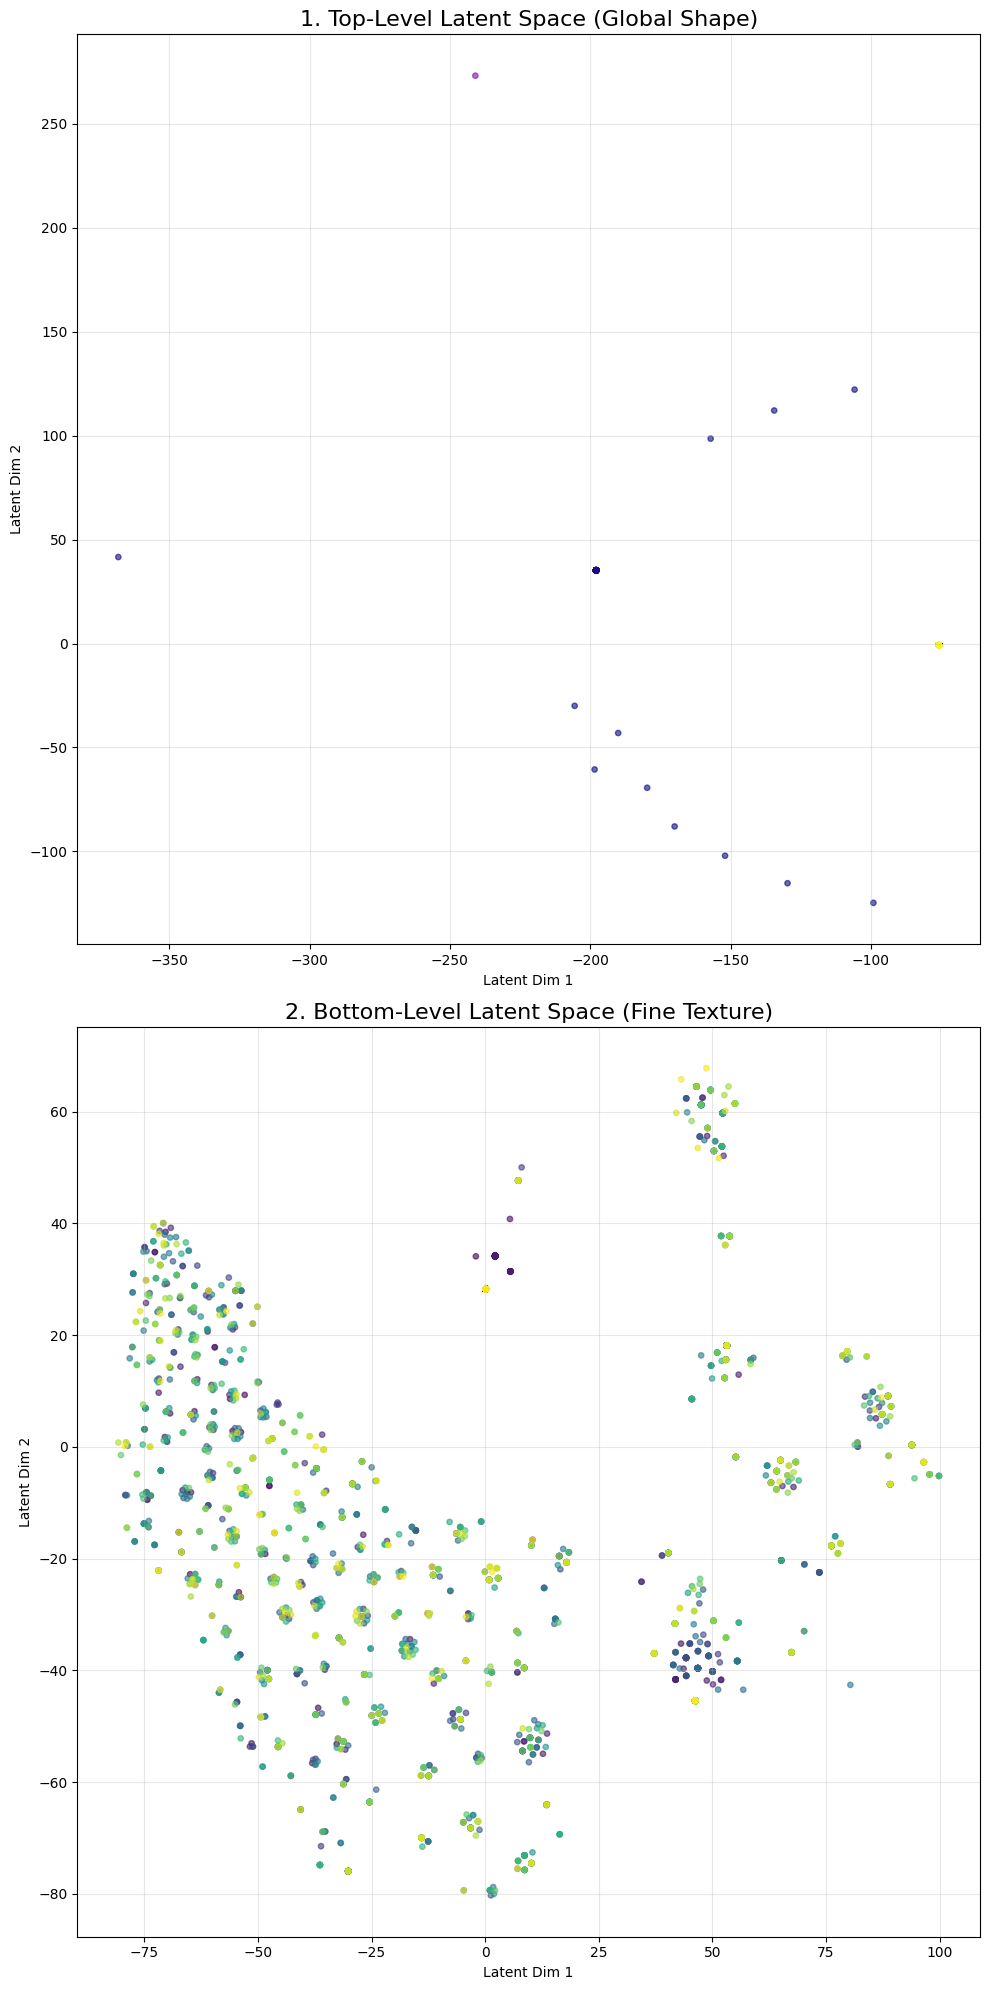

In [10]:
# --- ADDED MISSING IMPORTS ---
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

def visualize_vqvae_latent_vertical(model, loader):
    model.eval()
    
    # Store latents
    latents_top = []
    latents_bottom = []
    
    print("Extracting VQ-VAE-2 Hierarchical Latents...")
    
    with torch.no_grad():
        for i, images in enumerate(loader):
            if i * Config.BATCH_SIZE >= 1000: break # Limit to 1000 samples for speed
            images = images.to(Config.DEVICE)
            
            # 1. Forward Pass to get Latents
            # We replicate the forward pass logic to grab the intermediates
            enc_b = model.enc_b(images)
            enc_t = model.enc_t(enc_b)
            
            quant_t, _, _ = model.quantize_t(model.quant_conv_t(enc_t))
            dec_t = model.dec_t(quant_t)
            feat_b = torch.cat([enc_b, dec_t], dim=1)
            quant_b, _, _ = model.quantize_b(model.quant_conv_b(feat_b))
            
            # Flatten and store
            # Top: [B, 64, 64, 64] -> Flatten to vectors
            latents_top.append(quant_t.permute(0, 2, 3, 1).reshape(-1, Config.EMBED_DIM).cpu().numpy())
            
            # Bottom: [B, 64, 128, 128] -> Flatten to vectors
            # We subsample the bottom level because 128x128 is huge (too slow for t-SNE)
            # We take every 16th vector to keep the visualization fast
            lb = quant_b.permute(0, 2, 3, 1).reshape(-1, Config.EMBED_DIM)
            latents_bottom.append(lb[::16].cpu().numpy()) 

    # Concatenate batches
    latents_top = np.concatenate(latents_top, axis=0)
    latents_bottom = np.concatenate(latents_bottom, axis=0)
    
    # Limit for t-SNE (it's slow on >3000 points)
    limit = 3000
    if len(latents_top) > limit: 
        # Randomly sample if too many
        indices = np.random.choice(len(latents_top), limit, replace=False)
        latents_top = latents_top[indices]
        
    if len(latents_bottom) > limit: 
        indices = np.random.choice(len(latents_bottom), limit, replace=False)
        latents_bottom = latents_bottom[indices]

    print(f"Running t-SNE on Top Level ({len(latents_top)} vectors)...")
    tsne = TSNE(n_components=2, random_state=42)
    top_tsne = tsne.fit_transform(latents_top)
    
    print(f"Running t-SNE on Bottom Level ({len(latents_bottom)} vectors)...")
    bottom_tsne = tsne.fit_transform(latents_bottom)
    
    # --- PLOTTING (VERTICAL) ---
    fig, axes = plt.subplots(2, 1, figsize=(10, 20))
    
    # Plot 1: Top Level
    scatter1 = axes[0].scatter(top_tsne[:, 0], top_tsne[:, 1], c=np.arange(len(top_tsne)), cmap='plasma', alpha=0.6, s=15)
    axes[0].set_title("1. Top-Level Latent Space (Global Shape)", fontsize=16)
    axes[0].set_xlabel("Latent Dim 1")
    axes[0].set_ylabel("Latent Dim 2")
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Bottom Level
    scatter2 = axes[1].scatter(bottom_tsne[:, 0], bottom_tsne[:, 1], c=np.arange(len(bottom_tsne)), cmap='viridis', alpha=0.6, s=15)
    axes[1].set_title("2. Bottom-Level Latent Space (Fine Texture)", fontsize=16)
    axes[1].set_xlabel("Latent Dim 1")
    axes[1].set_ylabel("Latent Dim 2")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(Config.SAVE_DIR, "vqvae2_latent_space_vertical.png"))
    plt.show()

# Run it
print("Loading Best VQ-VAE-2...")
model_path = os.path.join(Config.SAVE_DIR, "best_vqvae2_lpips.pth")
if not os.path.exists(model_path):
    model_path = os.path.join(Config.SAVE_DIR, "best_vqvae2.pth")

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    visualize_vqvae_latent_vertical(model, test_loader)
else:
    print("❌ Error: Model file not found. Please check training.")